In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [3]:
df= sns.load_dataset('diamonds')

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [7]:
df['cut'].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

we can encode 'cut' with labelencoder

In [8]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
encoded= le.fit_transform(df['cut'])
df['cut']=encoded

In [9]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75


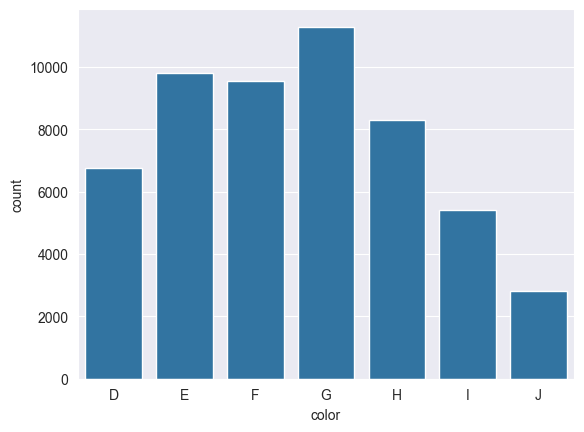

In [10]:
sns.countplot(x='color', data=df)
plt.show()

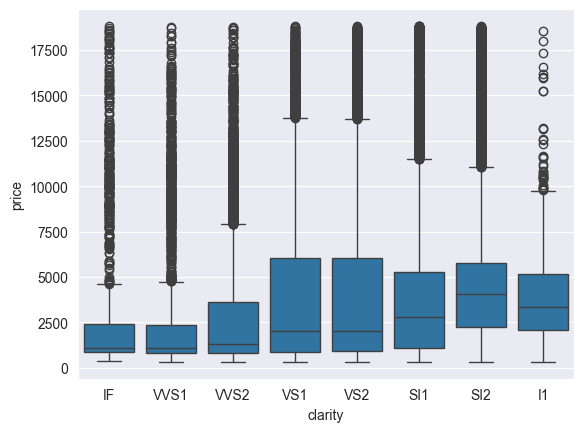

In [11]:
sns.boxplot(x='clarity', y='price', data=df)
plt.show()

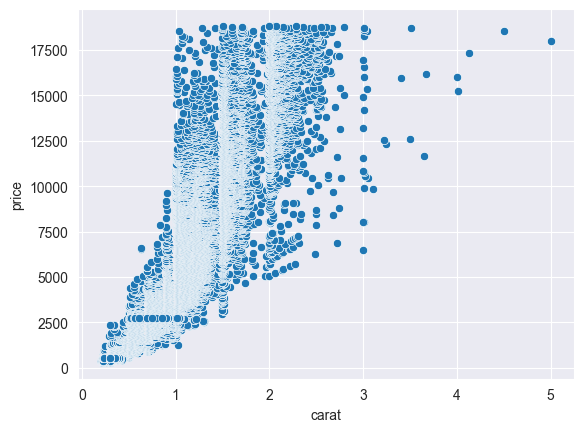

In [12]:
sns.scatterplot(x='carat', y='price', data=df)
plt.show()

In [13]:
df.corr(numeric_only=True)

,carat,cut,depth,table,price,x,y,z
carat,1.000000,0.017124,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
cut,0.017124,1.000000,-0.194249,0.150327,0.039860,0.022342,0.027572,0.002037
depth,0.028224,-0.194249,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,0.150327,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,0.039860,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,0.022342,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,0.027572,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.002037,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


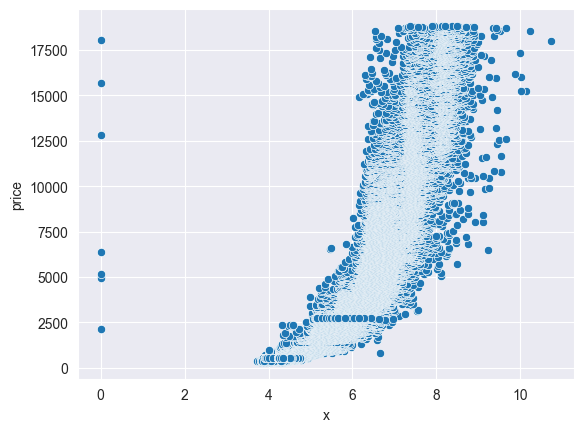

In [14]:
sns.scatterplot(x='x', y='price',  data=df)
plt.show()


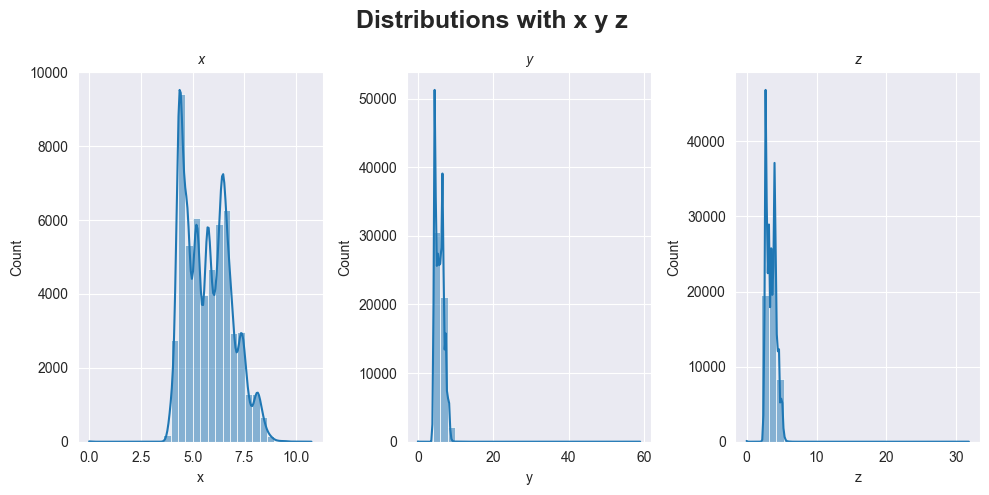

In [15]:

fig , ax = plt.subplots(ncols=3,nrows=1,figsize=(10,5))
fig.suptitle("Distributions with x y z ", fontsize = 18, fontweight = "bold")
ax[0]= sns.histplot(data = df, x = df['x'], kde=True, ax=ax[0], bins=30)
ax[0].set_title('x', fontsize=10, fontstyle = "italic")
ax[1]= sns.histplot(data = df, x = df['y'], kde=True, ax=ax[1], bins=30)
ax[1].set_title('y', fontsize=10, fontstyle = "italic")
ax[2]= sns.histplot(data = df, x = df['z'], kde=True, ax=ax[2], bins=30)
ax[2].set_title('z', fontsize=10, fontstyle = "italic")

plt.tight_layout()
plt.show()

In [16]:
X=df.drop('price',axis=1)
y=df['price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
df['color'].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [19]:
df['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [20]:
df['color'] = df['color'].str.lower()
df['clarity'] = df['clarity'].str.lower()

In [21]:
# i will use Columntransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['color', 'clarity'])
    ],
    remainder='passthrough'
)

In [22]:
X = ct.fit_transform(df)

In [23]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipeline = Pipeline([
    ('preprocessor', ct),
    ('model', XGBRegressor())
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred=pipeline.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error , root_mean_squared_error , classification_report , r2_score

def evaluate(y_true,y_pred):
    mse=mean_squared_error(y_true,y_pred)
    rmse=root_mean_squared_error(y_true,y_pred)
    r2=r2_score(y_true,y_pred)
    return mse,rmse,r2

In [26]:
mse,rmse,r2 =evaluate(y_test,y_pred)

In [27]:
print(f"mse:{mse}")
print(f"rmse: {rmse}")
print(f"r2: {r2}")

mse:342382.3125
rmse: 585.1344604492188
r2: 0.9784622192382812


In [28]:
params={
    "model__n_estimators" : [100, 200, 300],
    "model__learning_rate" : [0.01, 0.1],
    "model__max_depth" : [5,8,12]
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV
randomized= RandomizedSearchCV(estimator=pipeline,param_distributions=params,cv=5,verbose=1,n_jobs=-1)
randomized.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [5, 8, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [30]:
randomized.best_params_


{'model__n_estimators': 200,
 'model__max_depth': 8,
 'model__learning_rate': 0.1}

In [31]:
randomized.best_estimator_

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_withparameters=randomized.predict(X_test)

In [33]:
mse_withparameter,rmse_withparameter,r2_withparameter =evaluate(y_test,y_pred_withparameters)

In [34]:
print(f"mse:{mse_withparameter}")
print(f"rmse: {rmse_withparameter}")
print(f"r2: {r2_withparameter}")

mse:321305.15625
rmse: 566.8378295898438
r2: 0.979788064956665


In [36]:
model = pipeline.named_steps['model']
importances = model.feature_importances_

In [37]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(8)

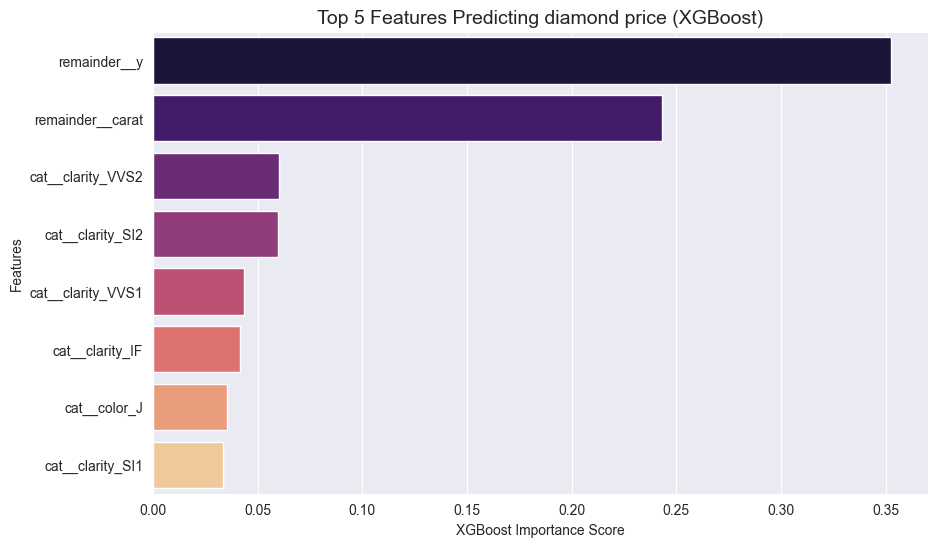

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance',y='feature',data=importance_df,palette='magma', hue='feature', legend=False)
plt.title('Top 5 Features Predicting diamond price (XGBoost)', fontsize=14)
plt.xlabel('XGBoost Importance Score')
plt.ylabel('Features')
plt.show()

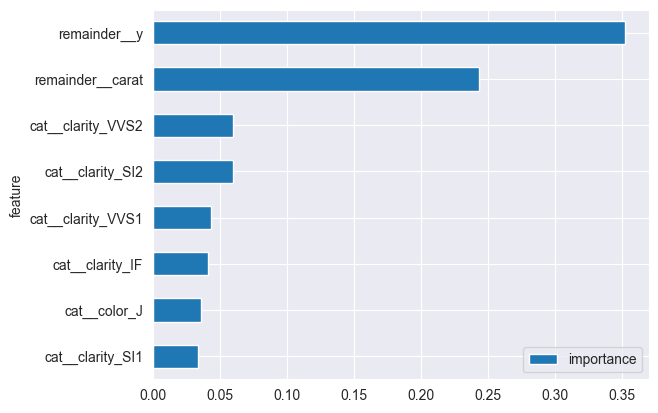

In [39]:
#another alternative

importance_df.head(10).plot(
    kind='barh',
    x='feature',
    y='importance'
)
plt.gca().invert_yaxis()
plt.show()